In [12]:
import numpy as np
from scipy.spatial import distance_matrix
import pandas as pd

cities = [
    'New York', 'Los Angeles', 'Dallas', 'Boston', 'Nashville', 'Phoenix',
    'Las Vegas', 'Louisville', 'Miami', 'Atlanta', 'Tucson', 'Denver',
    'Chicago', 'Minneapolis', 'St. Louis', 'Houston', 'New Orleans',
    'Charlotte', 'Philadelphia', 'Detroit', 'San Antonio', 'Kansas City',
    'Salt Lake City', 'Washington DC', 'Portland'
]

lat_lon = [
    [40.7128, -74.0060],
    [34.0549, -118.2426],
    [32.7767, -96.7970],
    [42.3555, -71.0565],
    [36.1627, -86.7816],
    [33.4483, -112.0725],
    [36.1716, -115.1391],
    [38.2469, -85.7664],
    [25.7617, -80.1918],
    [33.7501, -84.3885],
    [32.2540, -110.9742],
    [39.7392, -104.9903],
    [41.8832, -87.6324],
    [44.9778, -93.2650],
    [38.6274, -90.1982],
    [29.7601, -95.3701],
    [29.9509, -90.0758],
    [35.2216, -80.8401],
    [39.9526, -75.1652],
    [42.3297, -83.0425],
    [29.4252, -98.4946],
    [39.0997, -94.5783],
    [40.7606, -111.8762],
    [38.9072, -77.0369],
    [45.5152, -122.6784],
]
df = pd.DataFrame(lat_lon, columns=('lat', 'lon'), index=cities)

dfdf = pd.DataFrame(
    distance_matrix(df.values, df.values),
    index=df.index,
    columns=df.index
)

filename = 'datamatrix.csv'
dfdf.to_csv(filename)


In [13]:
c

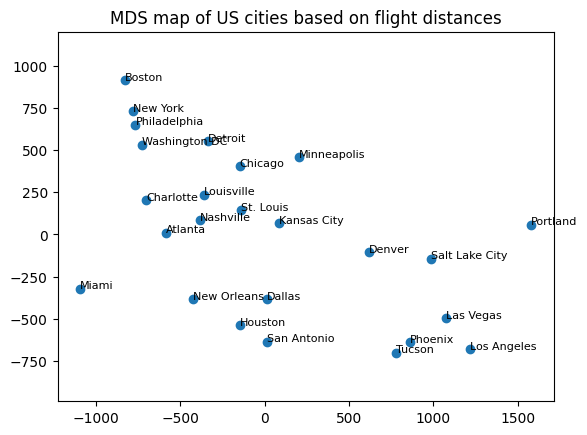

In [14]:
from sklearn.manifold import MDS
import matplotlib.pyplot as plt

'''This is the end of part 2.1. This is with using MDS to create a map of the cities'''
D = dfdf.values 

mds = MDS(
    n_components=2,
    dissimilarity='precomputed',
    random_state=0,
    n_init=4,
    max_iter=300
)
X_2d = mds.fit_transform(D) 

plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1])

for i, city in enumerate(cities):
    plt.text(X_2d[i, 0], X_2d[i, 1], city, fontsize=8)

plt.axis('equal')
plt.title("MDS map of US cities based on flight distances")
plt.show()
